<a href="https://colab.research.google.com/github/sdishita6/Create_visualizations_for_using_matplotlib-_seaborn_-_folium/blob/main/Create_visualizations_for_using_matplotlib%2C_seaborn_%2C_folium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install dash plotly folium

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "Year": np.repeat(np.arange(2010, 2020), 20),
    "Sales": np.random.randint(200, 1000, 200),
    "Advertising_Expenditure": np.random.randint(50, 300, 200),
    "Vehicle_Type": np.random.choice(["SUV", "Sedan", "Truck"], 200),
    "Recession": np.random.choice([0,1], 200),
    "GDP": np.random.randint(1000, 5000, 200),
    "Unemployment_Rate": np.random.uniform(3, 10, 200),
    "Price": np.random.randint(20000, 50000, 200),
    "Month": np.random.randint(1,13,200),
    "Seasonality_Index": np.random.uniform(0.5,1.5,200)
})

df.head()

,Year,Sales,Advertising_Expenditure,Vehicle_Type,Recession,GDP,Unemployment_Rate,Price,Month,Seasonality_Index
0,2010,302,165,Sedan,1,1684,5.775799,26359,7,1.259036
1,2010,635,254,SUV,1,3719,7.354607,27863,11,1.224103
2,2010,470,282,Truck,0,3220,9.036546,23228,8,1.137232
3,2010,306,52,SUV,0,2852,9.646644,40103,6,1.480577
4,2010,271,152,SUV,1,1814,4.029514,47804,9,1.403364


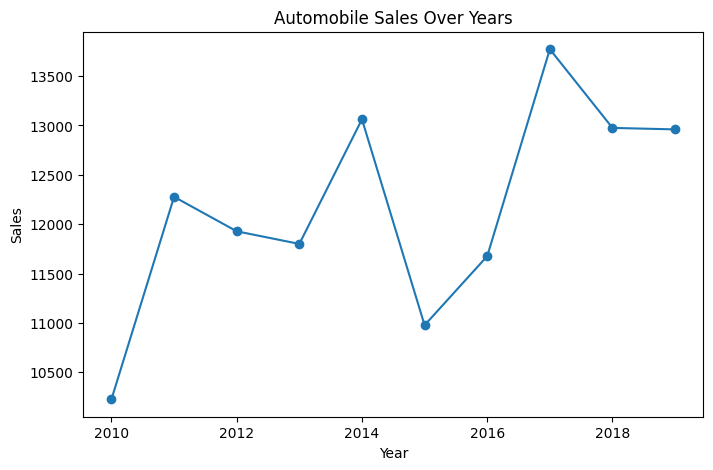

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

year_sales = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.plot(year_sales.index, year_sales.values, marker='o')
plt.title("Automobile Sales Over Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

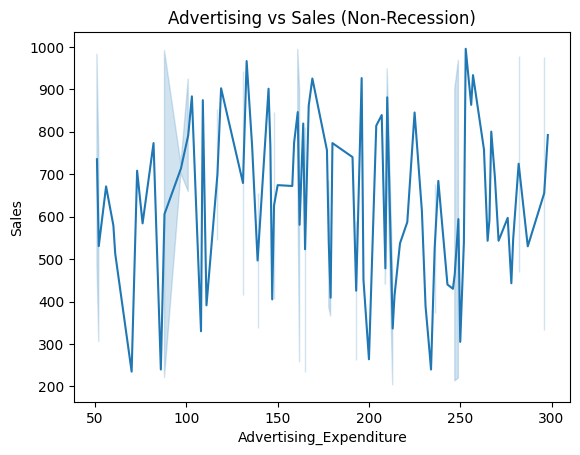

In [6]:
non_rec = df[df["Recession"] == 0]

sns.lineplot(data=non_rec, x="Advertising_Expenditure", y="Sales")
plt.title("Advertising vs Sales (Non-Recession)")
plt.show()

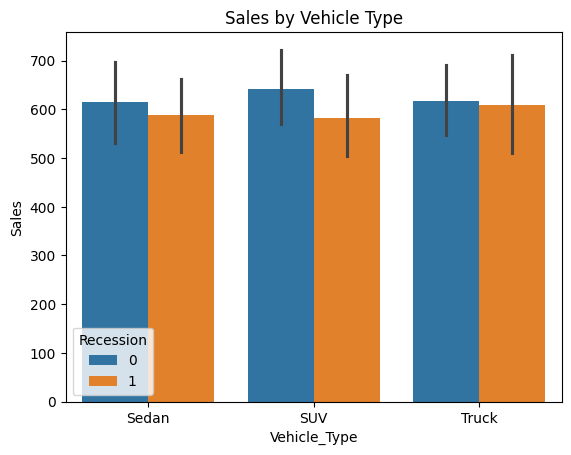

In [7]:
sns.barplot(data=df, x="Vehicle_Type", y="Sales", hue="Recession")
plt.title("Sales by Vehicle Type")
plt.show()

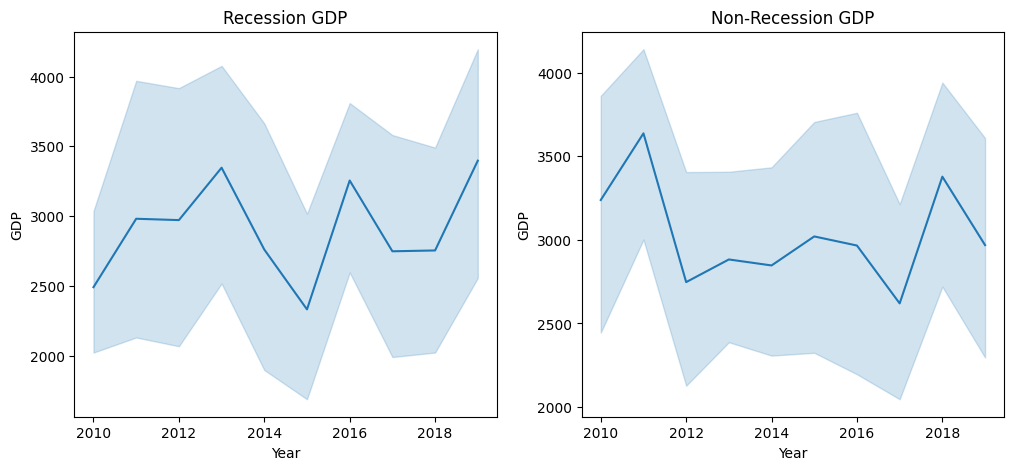

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.lineplot(data=df[df["Recession"]==1], x="Year", y="GDP", ax=ax[0])
ax[0].set_title("Recession GDP")

sns.lineplot(data=df[df["Recession"]==0], x="Year", y="GDP", ax=ax[1])
ax[1].set_title("Non-Recession GDP")

plt.show()

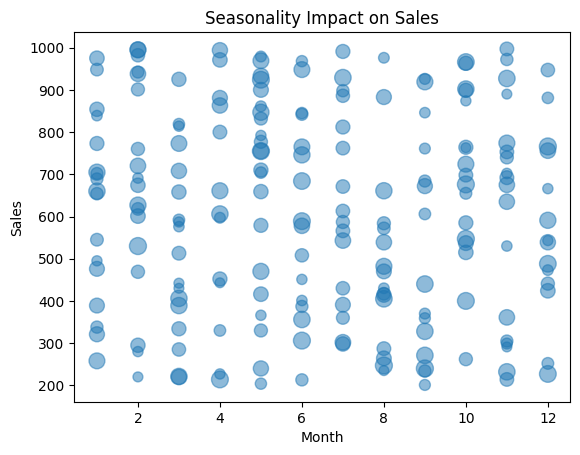

In [9]:
plt.scatter(df["Month"], df["Sales"],
            s=df["Seasonality_Index"]*100, alpha=0.5)

plt.title("Seasonality Impact on Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

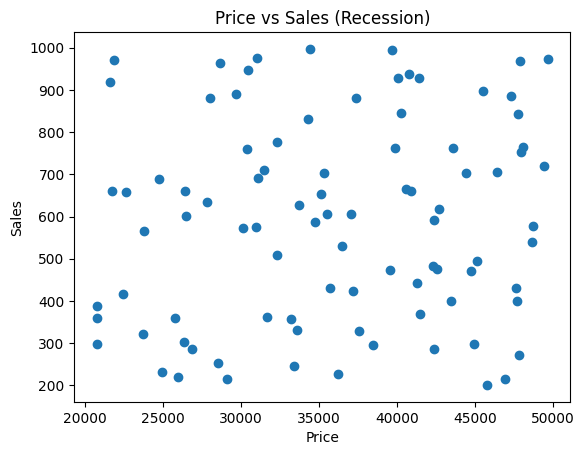

In [10]:
rec = df[df["Recession"]==1]

plt.scatter(rec["Price"], rec["Sales"])
plt.title("Price vs Sales (Recession)")
plt.xlabel("Price")
plt.ylabel("Sales")
plt.show()

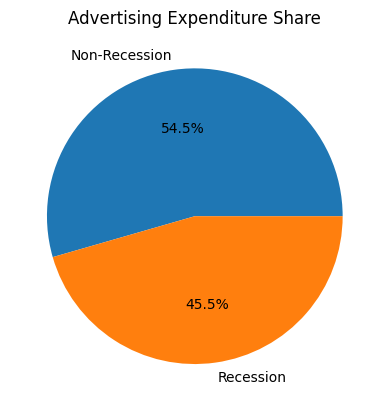

In [11]:
data = df.groupby("Recession")["Advertising_Expenditure"].sum()

plt.pie(data, labels=["Non-Recession","Recession"], autopct="%1.1f%%")
plt.title("Advertising Expenditure Share")
plt.show()

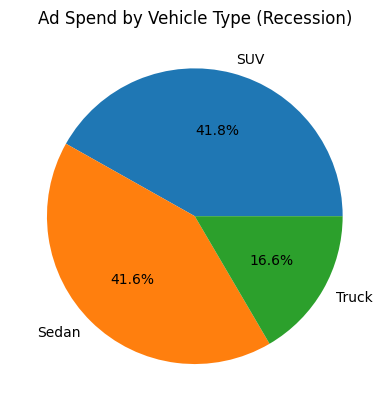

In [12]:
rec = df[df["Recession"]==1]
data = rec.groupby("Vehicle_Type")["Advertising_Expenditure"].sum()

plt.pie(data, labels=data.index, autopct="%1.1f%%")
plt.title("Ad Spend by Vehicle Type (Recession)")
plt.show()

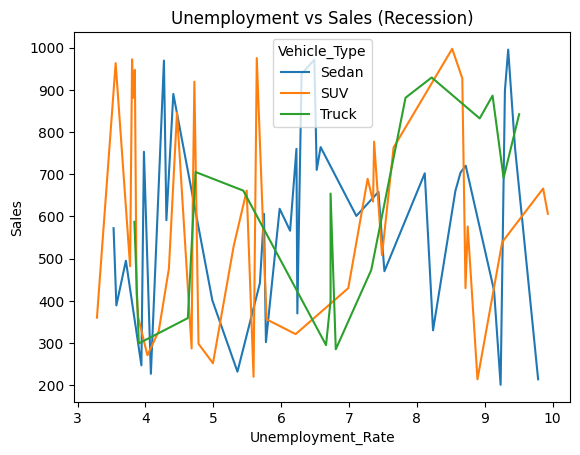

In [13]:
sns.lineplot(data=rec, x="Unemployment_Rate", y="Sales", hue="Vehicle_Type")
plt.title("Unemployment vs Sales (Recession)")
plt.show()

In [14]:
import folium

m = folium.Map(location=[23.2599, 77.4126], zoom_start=5)
m